In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df = pd.read_csv("generated_crystals_cifs/voltage_analysis.csv")
df_old100 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_old2048 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_train = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20/train.csv")
df_train_diff_add1 = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20_diff_add1/train.csv")

In [8]:
df

,pretty_formula,filename,num_atoms,host_energy,Li_energy,Na_energy,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,host_structure,Li_structure,Na_structure
0,LiCrO2,gen_0,4.0,-21.122227,-26.805637,-24.416141,-7.040742,-6.701409,-6.104035,0.740211,-0.725386,# generated using pymatgen\ndata_CrO2\n_symmet...,# generated using pymatgen\ndata_LiCrO2\n_symm...,# generated using pymatgen\ndata_NaCrO2\n_symm...
1,LiCr4O7,gen_1,12.0,-81.542628,-86.315765,-83.396968,-7.412966,-7.192980,-6.949747,-0.170063,-2.164960,# generated using pymatgen\ndata_Cr4O7\n_symme...,# generated using pymatgen\ndata_LiCr4O7\n_sym...,# generated using pymatgen\ndata_NaCr4O7\n_sym...
2,LiCr(Ni4O5)2,gen_10,20.0,-97.671985,-103.791458,-102.012335,-5.140631,-5.189573,-5.100617,1.176273,0.321049,# generated using pymatgen\ndata_Cr(Ni4O5)2\n_...,# generated using pymatgen\ndata_LiCr(Ni4O5)2\...,# generated using pymatgen\ndata_NaCr(Ni4O5)2\...
3,LiCr2O3,gen_100,6.0,-39.256724,-42.581903,-41.222241,-7.851345,-7.096984,-6.870373,-1.618022,-2.053784,# generated using pymatgen\ndata_Cr2O3\n_symme...,# generated using pymatgen\ndata_LiCr2O3\n_sym...,# generated using pymatgen\ndata_NaCr2O3\n_sym...
4,LiCr2O4,gen_1000,14.0,-88.737630,-98.508487,-94.393225,-7.394803,-7.036321,-6.742373,-0.057772,-1.191503,# generated using pymatgen\ndata_CrO2\n_symmet...,# generated using pymatgen\ndata_LiCr2O4\n_sym...,# generated using pymatgen\ndata_NaCr2O4\n_sym...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,LiCr(Ni2O3)2,gen_995,12.0,-60.079866,-65.882074,-64.366968,-5.461806,-5.490173,-5.363914,0.859008,0.267802,# generated using pymatgen\ndata_Cr(Ni2O3)2\n_...,# generated using pymatgen\ndata_LiCr(Ni2O3)2\...,# generated using pymatgen\ndata_NaCr(Ni2O3)2\...
2044,Cr3NiO6,gen_996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2045,VCr3O6,gen_997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2046,LiCrCoO3,gen_998,12.0,-68.807699,-79.114536,-76.166028,-6.880770,-6.592878,-6.347169,0.210218,-0.340136,# generated using pymatgen\ndata_CrCoO3\n_symm...,# generated using pymatgen\ndata_LiCrCoO3\n_sy...,# generated using pymatgen\ndata_NaCrCoO3\n_sy...


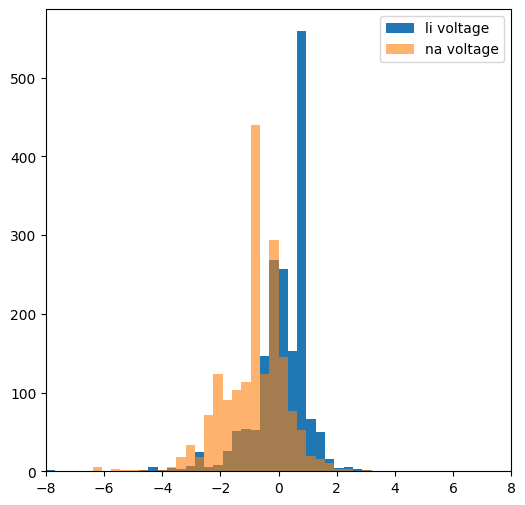

In [9]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage'],label="li voltage",bins=50,range=(-8,8))
plt.hist(df['Na_voltage'],label="na voltage",bins=50,range=(-8,8),alpha=0.6)
plt.xlim(-8,8)
plt.legend()
plt.show()

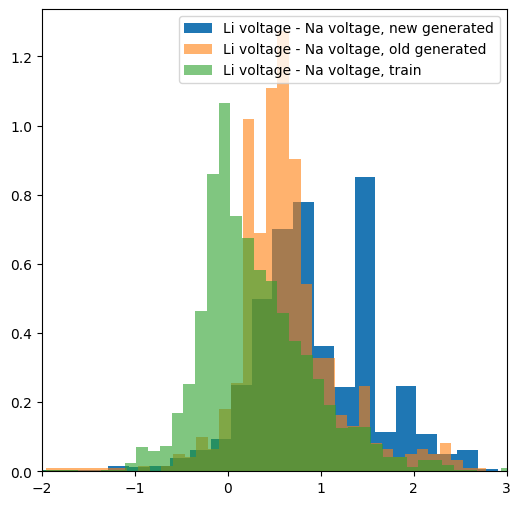

In [12]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage']-df['Na_voltage'],label="Li voltage - Na voltage, new generated",bins=50,density=True)
plt.hist(df_old2048['Li_voltage']-df_old2048['Na_voltage'],label="Li voltage - Na voltage, old generated",bins=50,alpha=0.6,density=True)
plt.hist(df_train['Li_voltage']-df_train['Na_voltage'],label="Li voltage - Na voltage, train",bins=50,alpha=0.6,density=True)
plt.xlim(-2,3)
plt.legend()
plt.show()

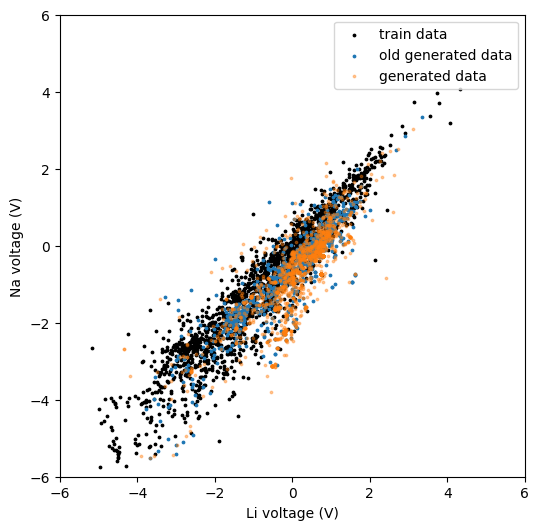

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="train data",c='k')
plt.scatter(df_old2048['Li_voltage'],df_old2048['Na_voltage'],s=3,label="old generated data")
plt.scatter(df['Li_voltage'],df['Na_voltage'],s=3,label="generated data", alpha=0.4)
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()

In [26]:
df_to_add = df[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']

/tmp/ipykernel_1996265/4151272627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']


In [27]:
df_old_to_add = df_old[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_old_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage'] 

/tmp/ipykernel_1996265/1798932268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage']


In [33]:
df_merged = pd.concat([df_train,df_to_add,df_old_to_add],ignore_index=True)

In [35]:
# remove nan rows except if Nan is only in 'material_id' column
df_merged_cleaned = df_merged.dropna(subset=['Li_voltage', 'Na_voltage', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom'])

In [37]:
df_merged_cleaned.to_csv("train_extended_cleaned.csv",index=False)

In [38]:
df_merged_cleaned

,pretty_formula,material_id,num_atoms,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,cif
0,Rb2LiBi2O5,mp-975106,10.0,-5.001463,-4.840352,-4.775824,-1.552852,-1.274225,# generated using pymatgen\ndata_Rb2LiBi2O5\n_...
1,LiVCl2O,mp-1216404,5.0,-5.365562,-5.168905,-4.801249,-0.560927,-1.475303,# generated using pymatgen\ndata_LiVCl2O\n_sym...
2,LiScTl(MoO4)2,mp-19450,13.0,-7.246476,-6.905751,-6.844393,-2.126157,-1.999905,# generated using pymatgen\ndata_LiScTl(MoO4)2...
3,Li4Cr3FeO8,mp-756058,16.0,-6.821576,-6.671563,-6.509723,0.678274,0.307453,# generated using pymatgen\ndata_Li4Cr3FeO8\n_...
4,Ba4Li(Co2O5)2,mp-1076439,19.0,-6.059365,-5.934136,-5.872205,-1.263181,-1.515970,# generated using pymatgen\ndata_Ba4Li(Co2O5)2...
...,...,...,...,...,...,...,...,...,...
3862,LiCr2NiO6,NaN,10.0,-6.418833,-6.344823,-6.205362,0.735528,0.470709,# generated using pymatgen\ndata_LiCr2NiO6\n_s...
3864,LiAlCr5O8,NaN,15.0,-7.741191,-7.435713,-7.356704,-1.784173,0.261232,# generated using pymatgen\ndata_LiAlCr5O8\n_s...
3866,LiCr2(NiO2)2,NaN,9.0,-6.042746,-5.595628,-5.691299,-2.924517,-1.784939,# generated using pymatgen\ndata_LiCr2(NiO2)2\...
3868,LiCr(SbO4)2,NaN,12.0,-6.106551,-6.136741,-6.015783,1.525626,0.527599,# generated using pymatgen\ndata_LiCr(SbO4)2\n...
